In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

COLORS = sns.color_palette("muted")
DATA = "../data/"

sales = pd.read_csv(DATA + "sales.csv", parse_dates=["Date"])
orders = pd.read_csv(DATA + "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA + "order_items.csv")
customers = pd.read_csv(DATA + "customers.csv", parse_dates=["signup_date"])
returns = pd.read_csv(DATA + "returns.csv", parse_dates=["return_date"])
web_traffic = pd.read_csv(DATA + "web_traffic.csv", parse_dates=["date"])
promotions = pd.read_csv(DATA + "promotions.csv", parse_dates=["start_date", "end_date"])
shipments = pd.read_csv(DATA + "shipments.csv")

print("Loaded tables:")
for name, df in [
    ("sales", sales),
    ("orders", orders),
    ("order_items", order_items),
    ("customers", customers),
    ("returns", returns),
    ("web_traffic", web_traffic),
    ("promotions", promotions),
]:
    print(f"  {name:12s} {df.shape}")
        


Loaded tables:
  sales        (3833, 3)
  orders       (646945, 8)
  order_items  (714669, 7)
  customers    (121930, 7)
  returns      (39939, 7)
  web_traffic  (3652, 7)
  promotions   (50, 10)


In [ ]:
products = pd.read_csv('../data/products.csv')
products.head(20)

## 1. Revenue trajectory: trend first, then margin quality

Doanh thu tăng/giảm theo thời gian như thế nào, và tăng trưởng đó có đi cùng biên lợi nhuận khỏe hay không.

- Dùng **monthly revenue** thay vì daily revenue để giảm nhiễu.
- Thêm **12-month rolling mean** để nhìn được xu hướng dài hạn.
- Tách **gross margin %** xuống panel riêng để tránh trộn đơn vị đo.
        


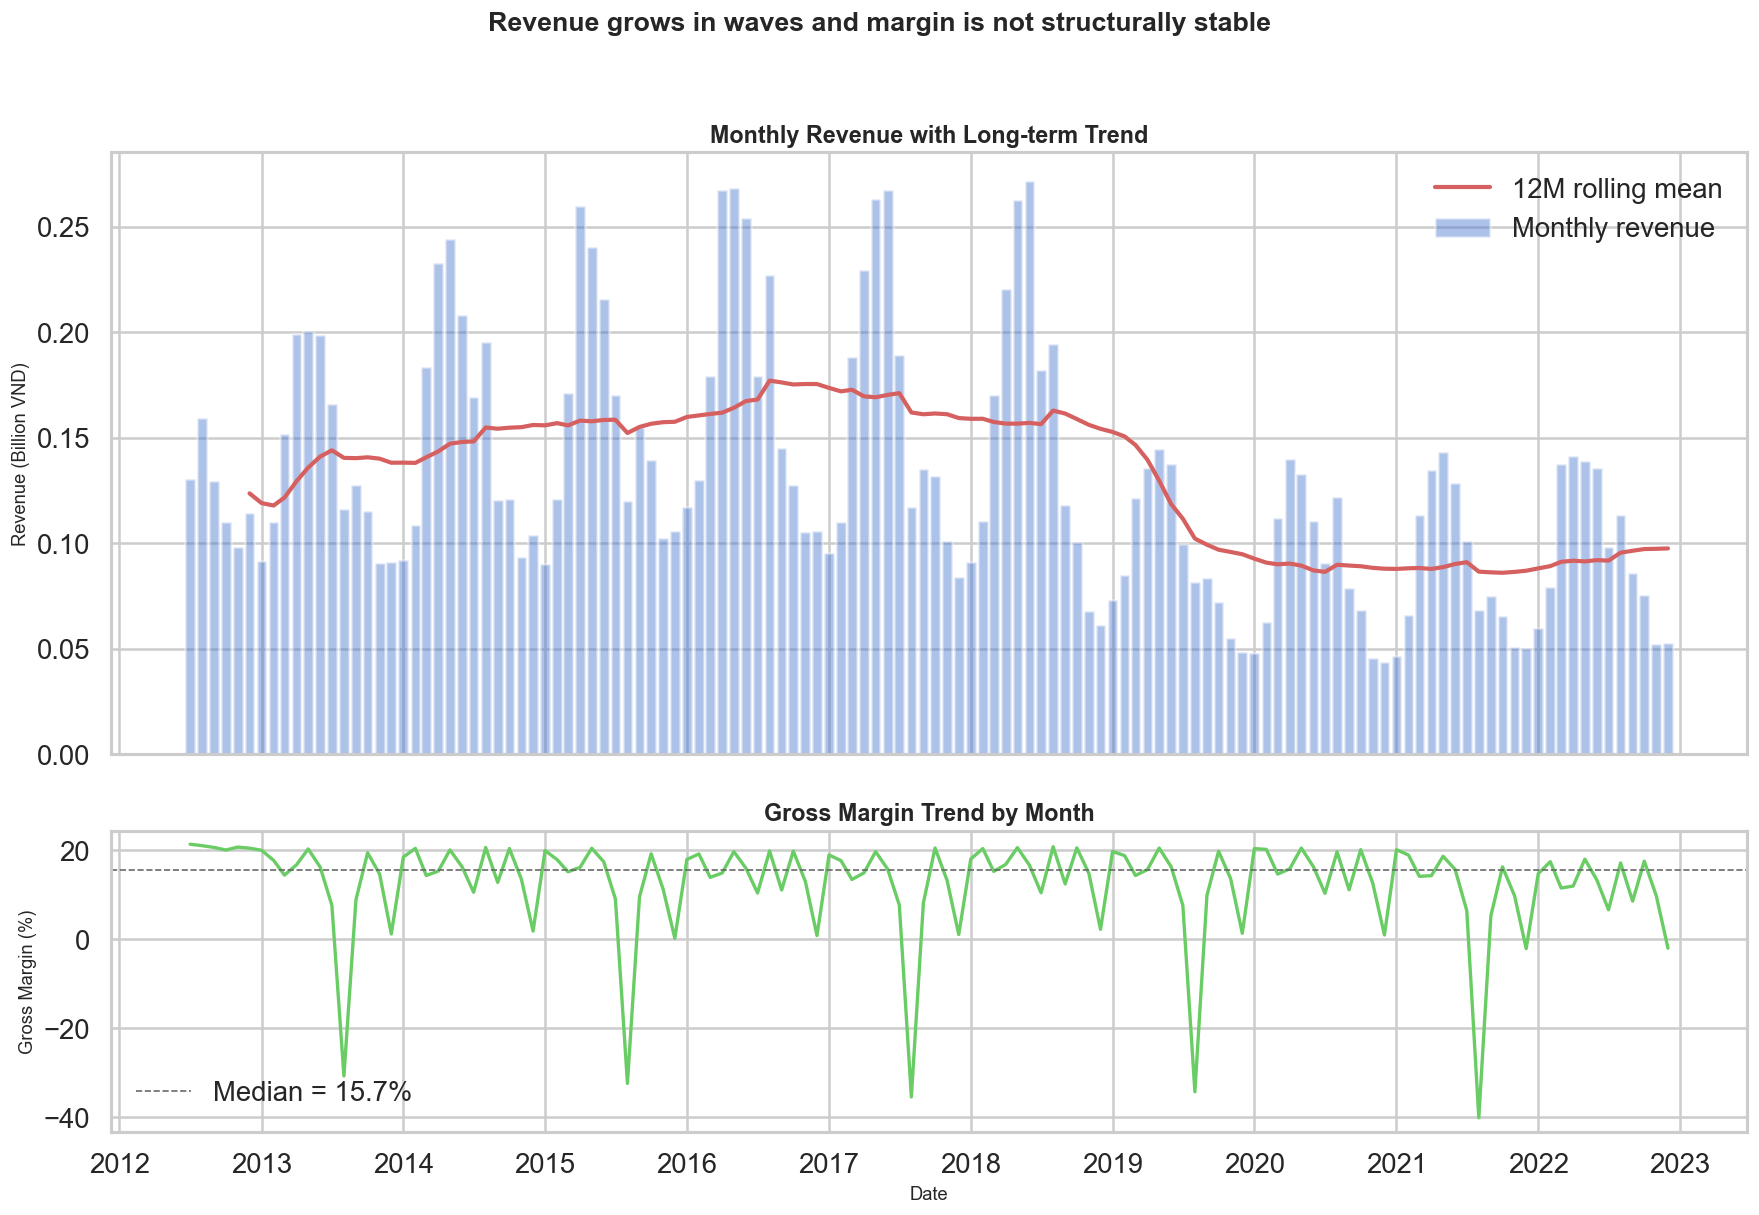

,Revenue,COGS,GrossMarginPct
year,,,
2012,7.414977e+08,5.874619e+08,20.77
2013,1.657169e+09,1.465980e+09,11.54
2014,1.871846e+09,1.574607e+09,15.88
2015,1.889934e+09,1.665442e+09,11.88
2016,2.104641e+09,1.780559e+09,15.40
2017,1.911164e+09,1.694386e+09,11.34
2018,1.850122e+09,1.542176e+09,16.64
2019,1.136801e+09,1.005203e+09,11.58
2020,1.054512e+09,8.860851e+08,15.97


In [2]:
monthly_sales = (
    sales.assign(YearMonth=sales["Date"].dt.to_period("M").dt.to_timestamp())
         .groupby("YearMonth", as_index=False)[["Revenue", "COGS"]]
         .sum()
)
monthly_sales["GrossProfit"] = monthly_sales["Revenue"] - monthly_sales["COGS"]
monthly_sales["GrossMarginPct"] = monthly_sales["GrossProfit"] / monthly_sales["Revenue"] * 100
monthly_sales["RevenueRolling12M"] = monthly_sales["Revenue"].rolling(12, min_periods=6).mean()

fig, axes = plt.subplots(
    2, 1, figsize=(15, 10), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

axes[0].bar(
    monthly_sales["YearMonth"],
    monthly_sales["Revenue"] / 1e9,
    width=25,
    color=COLORS[0],
    alpha=0.45,
    label="Monthly revenue"
)
axes[0].plot(
    monthly_sales["YearMonth"],
    monthly_sales["RevenueRolling12M"] / 1e9,
    color=COLORS[3],
    linewidth=2.5,
    label="12M rolling mean"
)
axes[0].set_title("Monthly Revenue with Long-term Trend")
axes[0].set_ylabel("Revenue (Billion VND)")
axes[0].legend(loc="upper right")

axes[1].plot(
    monthly_sales["YearMonth"],
    monthly_sales["GrossMarginPct"],
    color=COLORS[2],
    linewidth=2
)
axes[1].axhline(
    monthly_sales["GrossMarginPct"].median(),
    linestyle="--",
    color="dimgray",
    linewidth=1,
    label=f"Median = {monthly_sales['GrossMarginPct'].median():.1f}%"
)
axes[1].set_title("Gross Margin Trend by Month")
axes[1].set_ylabel("Gross Margin (%)")
axes[1].set_xlabel("Date")
axes[1].legend(loc="lower left")
axes[1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Revenue grows in waves and margin is not structurally stable", y=1.02, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

annual_summary = (
    monthly_sales.assign(year=monthly_sales["YearMonth"].dt.year)
                .groupby("year")[["Revenue", "COGS"]]
                .sum()
)
annual_summary["GrossMarginPct"] = (annual_summary["Revenue"] - annual_summary["COGS"]) / annual_summary["Revenue"] * 100
display(annual_summary.round(2))
        


**Interpretation**

- Revenue không đi theo một xu hướng tăng mượt; nó có những pha bùng lên rồi chững lại, vì vậy series khó được xem là stationary.
- Gross margin dao động khá mạnh giữa các năm/tháng, cho thấy cùng một mức doanh thu chưa chắc mang lại cùng chất lượng lợi nhuận.
- Với forecasting, đây là tín hiệu rằng chỉ dùng trend tuyến tính là chưa đủ; mô hình cần nắm được cả seasonality lẫn những giai đoạn margin compression/expansion.
        


## 2. Seasonality
        


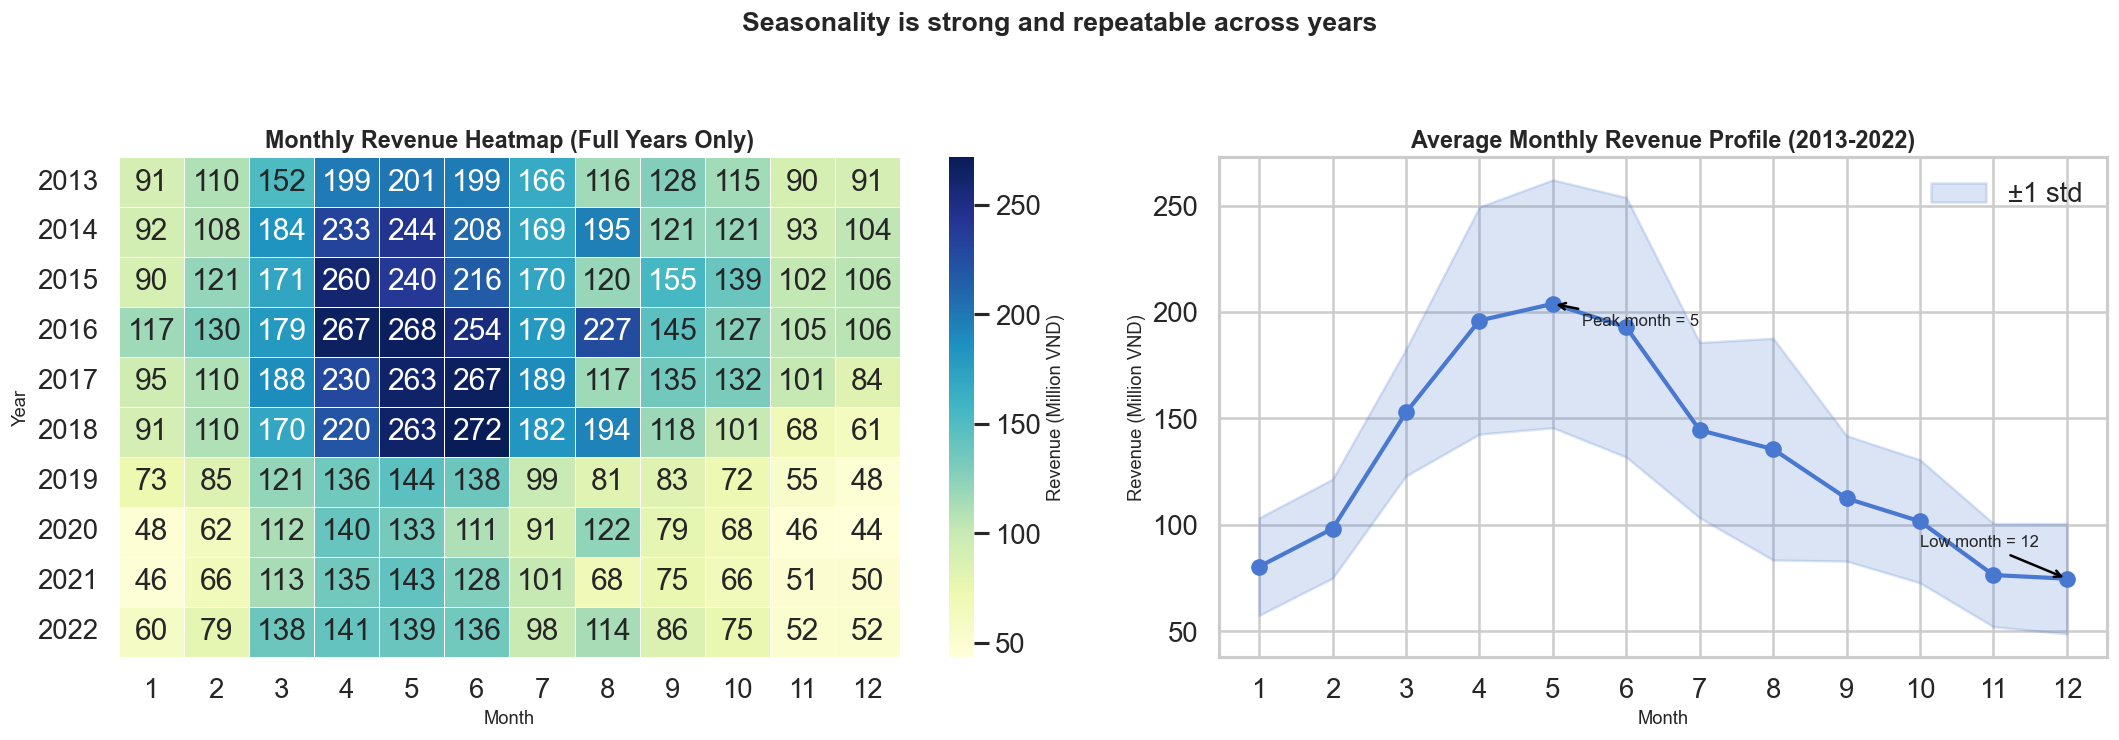

In [3]:
monthly_full_years = monthly_sales[
    monthly_sales["YearMonth"].dt.year.between(2013, 2022)
].copy()
monthly_full_years["Year"] = monthly_full_years["YearMonth"].dt.year
monthly_full_years["Month"] = monthly_full_years["YearMonth"].dt.month

seasonality_pivot = monthly_full_years.pivot(index="Year", columns="Month", values="Revenue") / 1e6
seasonality_profile = (
    monthly_full_years.groupby("Month")["Revenue"]
    .agg(avg_revenue="mean", std_revenue="std")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [1.1, 1]})

sns.heatmap(
    seasonality_pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Revenue (Million VND)"},
    ax=axes[0]
)
axes[0].set_title("Monthly Revenue Heatmap (Full Years Only)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Year")

axes[1].plot(
    seasonality_profile["Month"],
    seasonality_profile["avg_revenue"] / 1e6,
    color=COLORS[0],
    marker="o",
    linewidth=2.5
)
axes[1].fill_between(
    seasonality_profile["Month"],
    (seasonality_profile["avg_revenue"] - seasonality_profile["std_revenue"]) / 1e6,
    (seasonality_profile["avg_revenue"] + seasonality_profile["std_revenue"]) / 1e6,
    color=COLORS[0],
    alpha=0.2,
    label="±1 std"
)
axes[1].set_xticks(range(1, 13))
axes[1].set_title("Average Monthly Revenue Profile (2013-2022)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Revenue (Million VND)")
axes[1].legend(loc="upper right")

peak_month = int(seasonality_profile.loc[seasonality_profile["avg_revenue"].idxmax(), "Month"])
trough_month = int(seasonality_profile.loc[seasonality_profile["avg_revenue"].idxmin(), "Month"])
axes[1].annotate(
    f"Peak month = {peak_month}",
    xy=(peak_month, seasonality_profile.loc[seasonality_profile["Month"] == peak_month, "avg_revenue"].iloc[0] / 1e6),
    xytext=(peak_month + 0.4, seasonality_profile["avg_revenue"].max() / 1e6 * 0.95),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=10
)
axes[1].annotate(
    f"Low month = {trough_month}",
    xy=(trough_month, seasonality_profile.loc[seasonality_profile["Month"] == trough_month, "avg_revenue"].iloc[0] / 1e6),
    xytext=(trough_month - 2.0, seasonality_profile["avg_revenue"].min() / 1e6 * 1.2),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=10
)

plt.suptitle("Seasonality is strong and repeatable across years", y=1.04, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()
        


**Interpretation**

- Seasonal pattern rất rõ: doanh thu thường mạnh ở giai đoạn **tháng 3-6** và suy yếu rõ vào **tháng 11-12**.
- Vì pattern lặp lại khá đều qua nhiều năm, seasonality nên là thành phần bắt buộc của pipeline forecast.
- Đây là loại insight có giá trị cao cho report, vì vừa trực quan vừa chuyển hóa trực tiếp thành feature engineering như `month`, `quarter`, Fourier terms hoặc seasonal lags.
        


## 3. Promotion intensity: higher promo penetration can lift volume but compress margin
**Theo thời gian, khi tỷ lệ đơn hàng có dùng promo tăng lên, doanh thu và gross margin thay đổi ra sao?**

- Tính **promo penetration ở cấp độ order**: một order được tính là promoted nếu có ít nhất một line item có `promo_id`.
- Loại bỏ order `cancelled`.
- Ghép với `sales.csv` theo tháng để nhìn đồng thời revenue, promo share và gross margin.
        


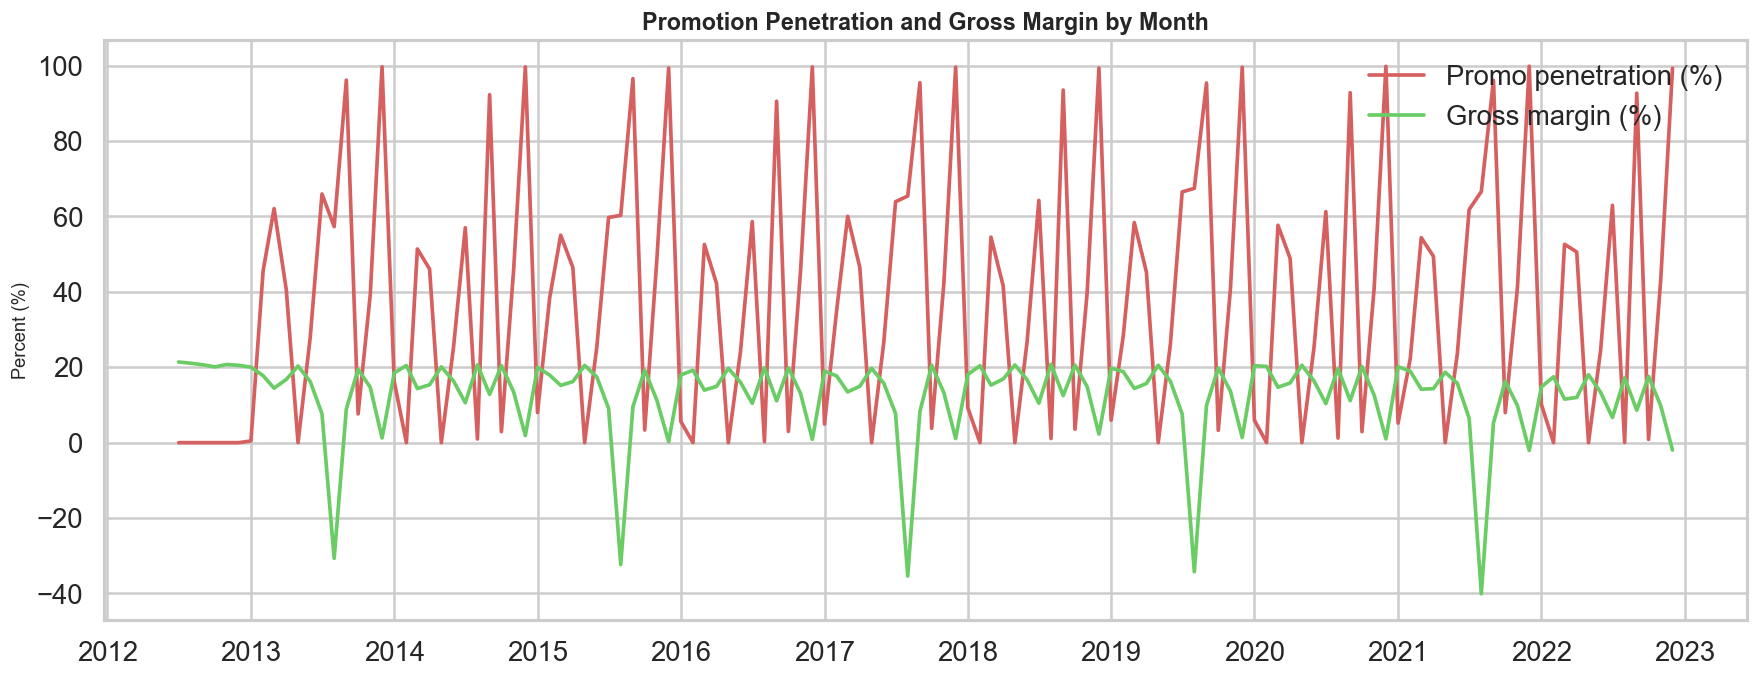

In [8]:
valid_orders = orders.loc[orders["order_status"] != "cancelled", ["order_id", "order_date"]].copy()
valid_orders["YearMonth"] = valid_orders["order_date"].dt.to_period("M").dt.to_timestamp()

order_promo_flag = (
    order_items.assign(has_promo=order_items["promo_id"].notna() & order_items["promo_id"].astype(str).ne(""))
               .groupby("order_id", as_index=False)["has_promo"]
               .max()
)

monthly_order_flags = (
    valid_orders.merge(order_promo_flag, on="order_id", how="left")
               .assign(has_promo=lambda df: df["has_promo"].fillna(False))
               .groupby("YearMonth")
               .agg(
                   total_orders=("order_id", "nunique"),
                   promoted_orders=("has_promo", "sum")
               )
               .reset_index()
)
monthly_order_flags["PromoPenetrationPct"] = monthly_order_flags["promoted_orders"] / monthly_order_flags["total_orders"] * 100

promo_margin = monthly_sales.merge(monthly_order_flags, on="YearMonth", how="left")

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(
    promo_margin["YearMonth"],
    promo_margin["PromoPenetrationPct"],
    color=COLORS[3],
    linewidth=2.2,
    label="Promo penetration (%)"
)
ax1.plot(
    promo_margin["YearMonth"],
    promo_margin["GrossMarginPct"],
    color=COLORS[2],
    linewidth=2.2,
    label="Gross margin (%)"
)
ax1.set_ylabel("Percent (%)")
ax1.tick_params(axis="y")

ax1.xaxis.set_major_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.set_title("Promotion Penetration and Gross Margin by Month")

ax1.legend(loc="upper right")

plt.tight_layout()
plt.show()
        


In [ ]:
monthly_orders = (
    orders.loc[orders["order_status"] != "cancelled", ["order_id", "order_date"]]
          .assign(YearMonth=lambda df: df["order_date"].dt.to_period("M").dt.to_timestamp())
          .groupby("YearMonth", as_index=False)["order_id"]
          .nunique()
          .rename(columns={"order_id": "total_orders"})
)

promo_months = promotions[["promo_id", "start_date", "end_date"]].copy()
promo_months["YearMonth"] = promo_months.apply(
    lambda row: pd.period_range(
        row["start_date"].to_period("M"),
        row["end_date"].to_period("M"),
        freq="ME"
    ).to_timestamp(),
    axis=1
)
promo_months = promo_months.explode("YearMonth")

monthly_active_promotions = (
    promo_months.groupby("YearMonth", as_index=False)["promo_id"]
               .nunique()
               .rename(columns={"promo_id": "active_promotions"})
)

monthly_orders_promotions = (
    monthly_orders.merge(monthly_active_promotions, on="YearMonth", how="left")
                  .fillna({"active_promotions": 0})
)
monthly_orders_promotions["active_promotions"] = monthly_orders_promotions["active_promotions"].astype(int)

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.bar(
    monthly_orders_promotions["YearMonth"],
    monthly_orders_promotions["total_orders"],
    width=25,
    color=COLORS[0],
    alpha=0.45,
    label="Total orders"
)
ax1.set_ylabel("Number of orders")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(
    monthly_orders_promotions["YearMonth"],
    monthly_orders_promotions["active_promotions"],
    color=COLORS[3],
    linewidth=2.2,
    marker="o",
    markersize=4,
    label="Active promotions"
)
ax2.set_ylabel("Number of active promotions")

ax1.xaxis.set_major_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.set_title("Monthly Orders and Active Promotions")

lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()
        


**Interpretation**
- Nếu những tháng promo penetration cao đi cùng doanh thu nhích lên nhưng gross margin giảm mạnh, ta có một trade-off rất thực tế: tăng volume bằng khuyến mãi không đồng nghĩa tăng chất lượng lợi nhuận.
- Với forecasting/report, chart này đặc biệt hữu ích vì nó gợi ý nên thử các feature như `promo_penetration`, `active_campaigns`, hoặc holiday/promo windows.
        


## 4. Traffic and order flow: demand is not just sales, it is also traffic x conversion x monetization

- Chuẩn hóa thành index = 100 để so sánh cùng nhịp.
- Tách riêng hai proxy chất lượng funnel:
  - `orders per 1k sessions`
  - `revenue per session`
        


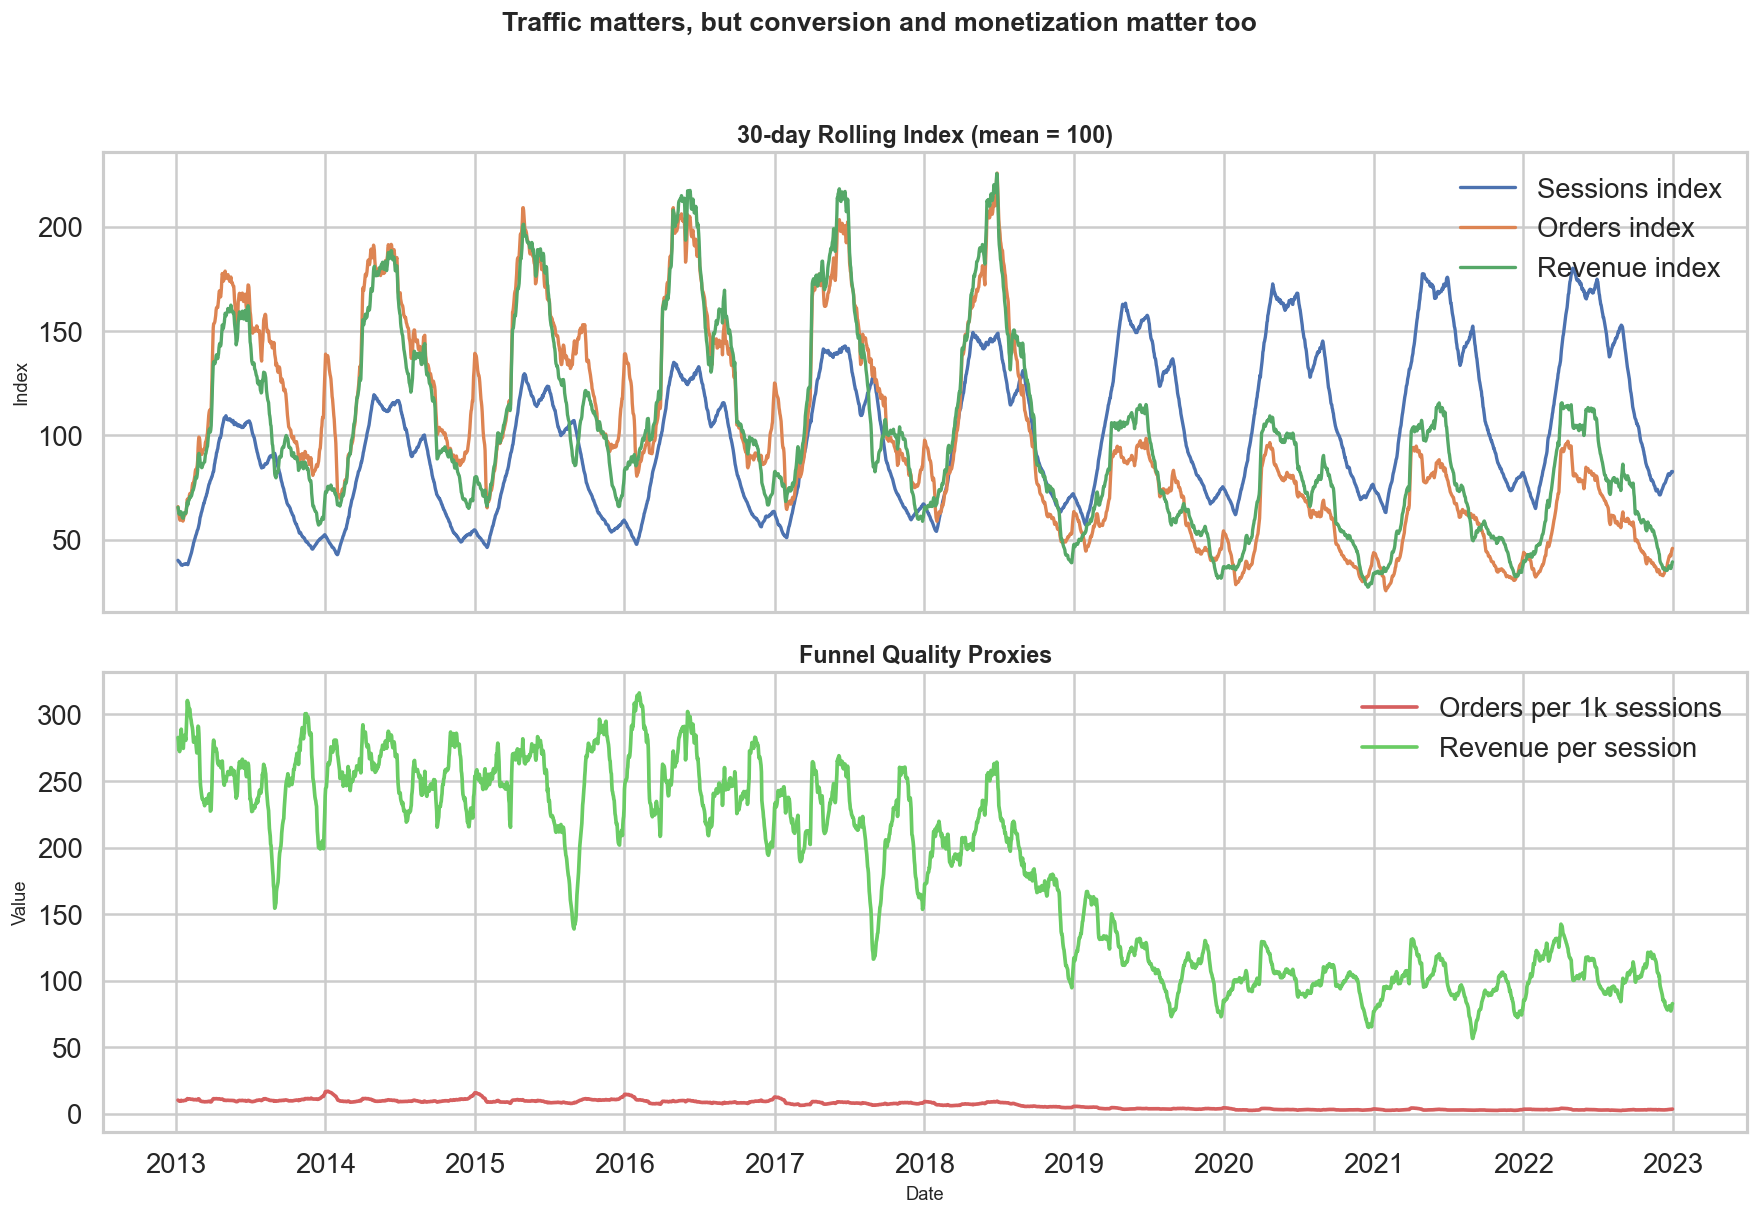

In [5]:
daily_orders = (
    orders.loc[orders["order_status"] != "cancelled"]
          .groupby("order_date")
          .agg(order_count=("order_id", "nunique"))
          .reset_index()
)

daily_revenue = sales.rename(columns={"Date": "date"})[["date", "Revenue"]].copy()

traffic_orders = (
    web_traffic.merge(daily_orders, left_on="date", right_on="order_date", how="inner")
               .merge(daily_revenue, on="date", how="inner")
               .sort_values("date")
)

for col in ["sessions", "order_count", "Revenue"]:
    traffic_orders[f"{col}_roll30"] = traffic_orders[col].rolling(30, min_periods=7).mean()
    traffic_orders[f"{col}_index"] = traffic_orders[f"{col}_roll30"] / traffic_orders[f"{col}_roll30"].mean() * 100

traffic_orders["orders_per_1k_sessions"] = traffic_orders["order_count"] / traffic_orders["sessions"] * 1000
traffic_orders["revenue_per_session"] = traffic_orders["Revenue"] / traffic_orders["sessions"]
traffic_orders["orders_per_1k_sessions_roll30"] = traffic_orders["orders_per_1k_sessions"].rolling(30, min_periods=7).mean()
traffic_orders["revenue_per_session_roll30"] = traffic_orders["revenue_per_session"].rolling(30, min_periods=7).mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].plot(traffic_orders["date"], traffic_orders["sessions_index"], label="Sessions index", linewidth=2.0)
axes[0].plot(traffic_orders["date"], traffic_orders["order_count_index"], label="Orders index", linewidth=2.0)
axes[0].plot(traffic_orders["date"], traffic_orders["Revenue_index"], label="Revenue index", linewidth=2.0)
axes[0].set_title("30-day Rolling Index (mean = 100)")
axes[0].set_ylabel("Index")
axes[0].legend(loc="upper right")

axes[1].plot(
    traffic_orders["date"],
    traffic_orders["orders_per_1k_sessions_roll30"],
    color=COLORS[3],
    linewidth=2.2,
    label="Orders per 1k sessions"
)
axes[1].plot(
    traffic_orders["date"],
    traffic_orders["revenue_per_session_roll30"],
    color=COLORS[2],
    linewidth=2.2,
    label="Revenue per session"
)
axes[1].set_title("Funnel Quality Proxies")
axes[1].set_ylabel("Value")
axes[1].set_xlabel("Date")
axes[1].legend(loc="upper right")
axes[1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Traffic matters, but conversion and monetization matter too", y=1.02, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()
        


**Interpretation**

- Nếu sessions, orders và revenue cùng nhịp, web traffic là một exogenous signal đáng cân nhắc.
- Nếu sessions tăng nhưng `orders per 1k sessions` giảm, doanh nghiệp đang mua traffic nhưng chất lượng funnel yếu đi.
- Nếu conversion ổn nhưng `revenue per session` giảm, vấn đề có thể đến từ mix sản phẩm, khuyến mãi hoặc AOV.
        


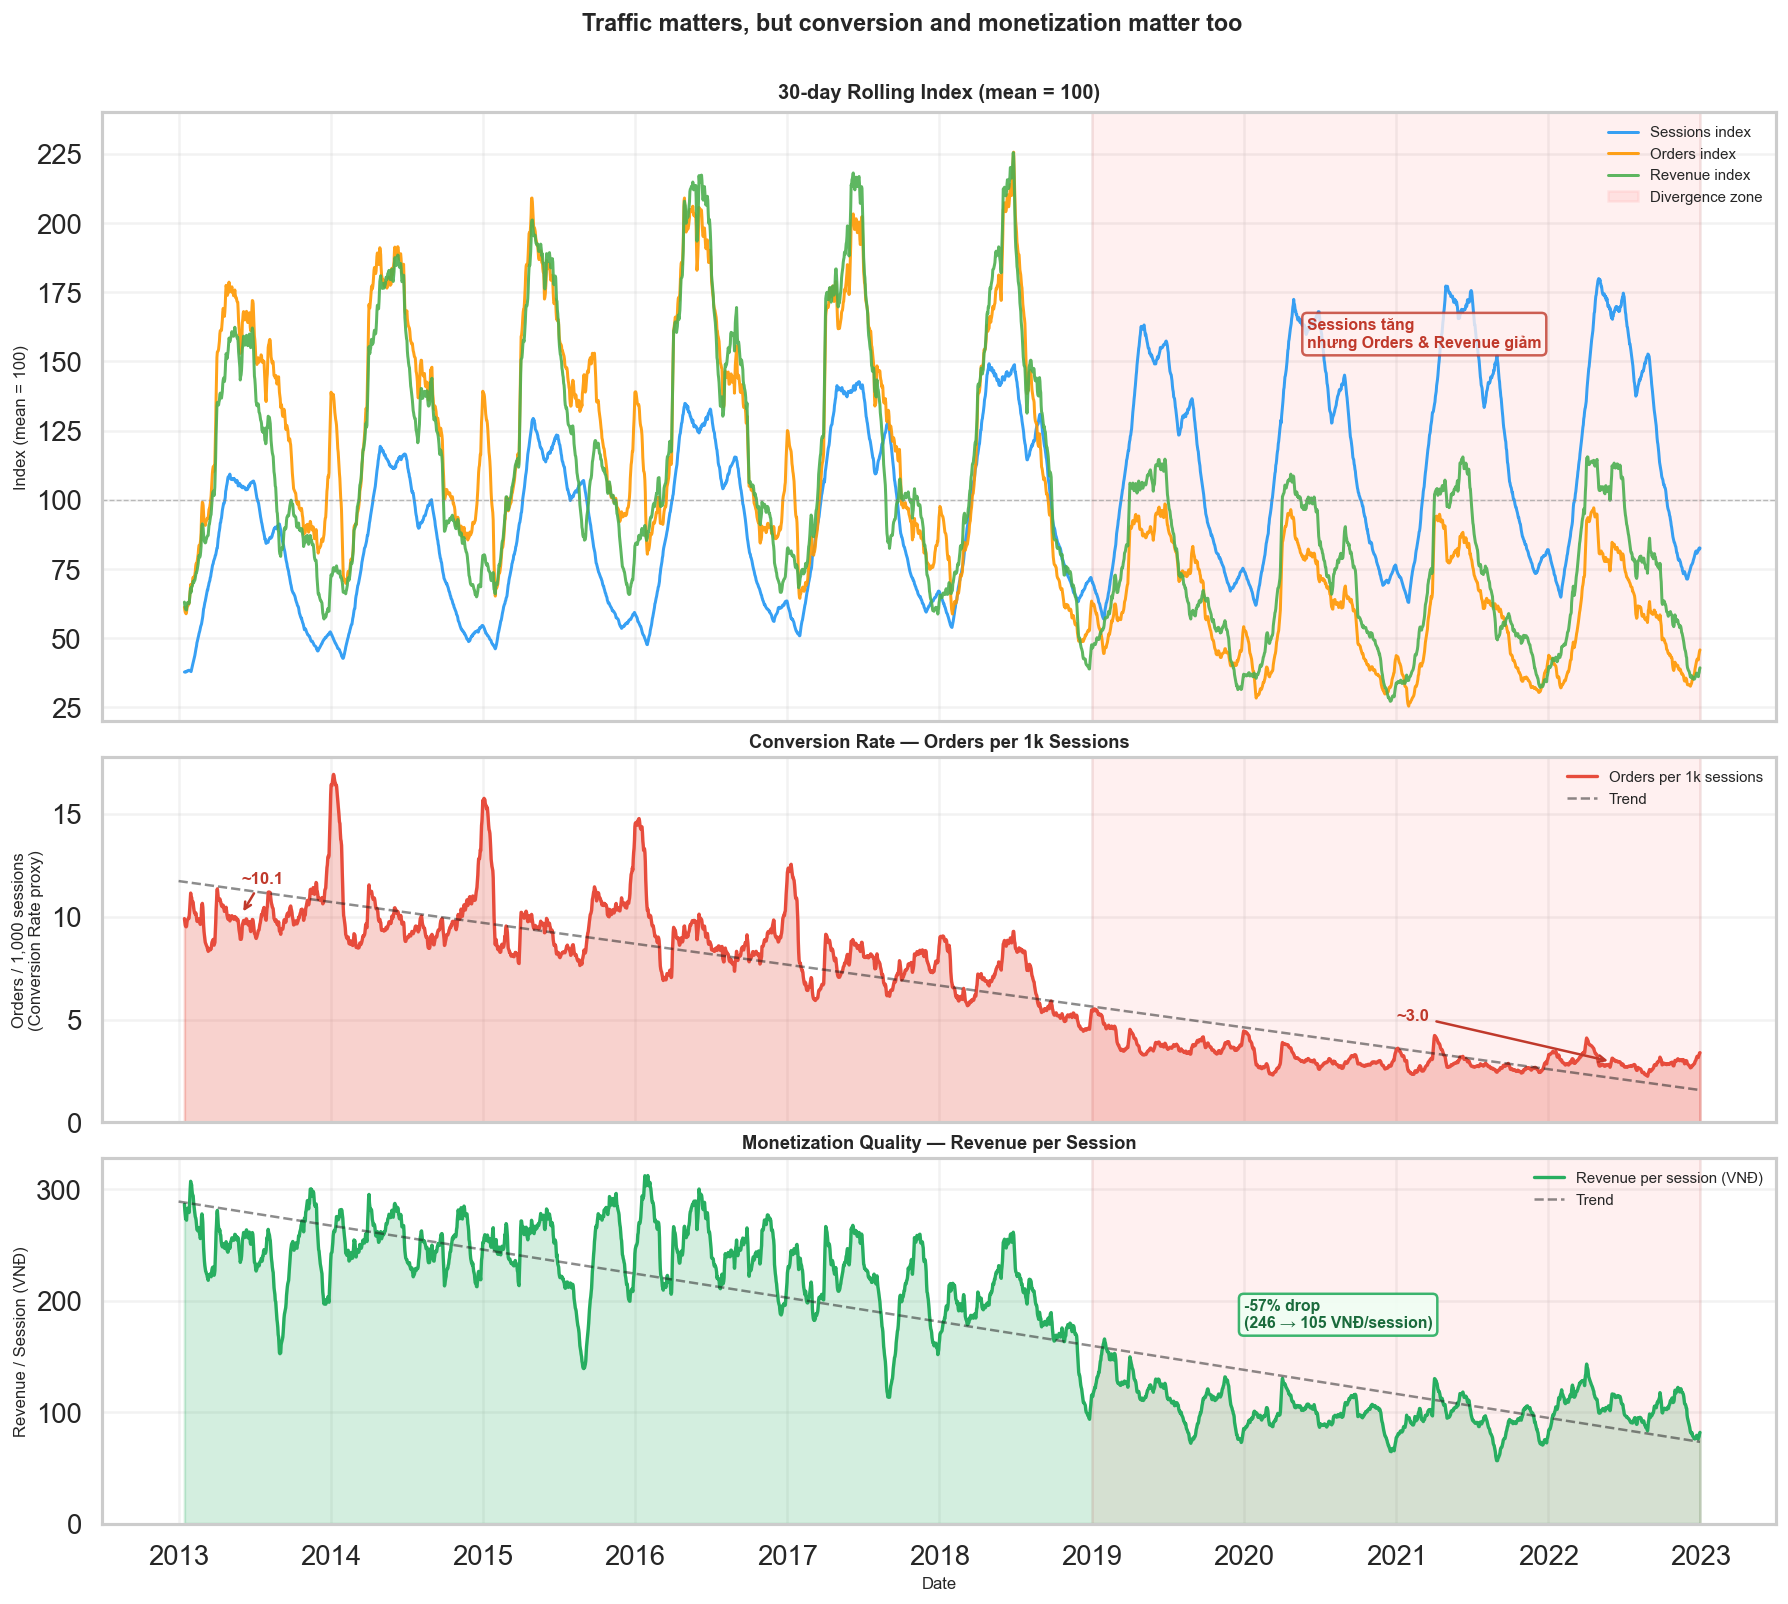

Conversion rate (Orders/1k sessions):
  2013 avg: 10.12
  2022 avg: 2.96
  Drop    : -70.8%

Revenue per session:
  2013 avg: 246 VNĐ
  2022 avg: 105 VNĐ
  Drop    : -57.1%


In [18]:
# ── Web Traffic Funnel Analysis — Fixed ──────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker

# ── Chuẩn bị dữ liệu ────────────────────────────────────────────────────────
wt = web_traffic.copy()
wt['date'] = pd.to_datetime(wt['date'])
wt = wt.sort_values('date')

# Daily orders từ orders.csv
ord_daily = (
    orders[orders['order_status'] != 'cancelled']
    .groupby('order_date')['order_id'].count()
    .reset_index()
    .rename(columns={'order_date': 'date', 'order_id': 'n_orders'})
)
ord_daily['date'] = pd.to_datetime(ord_daily['date'])

# Daily revenue từ sales.csv
rev_daily = sales[['Date', 'Revenue']].rename(columns={'Date': 'date'})
rev_daily['date'] = pd.to_datetime(rev_daily['date'])

# Merge
df = wt.merge(ord_daily, on='date', how='left')
df = df.merge(rev_daily,  on='date', how='left')
df['n_orders']  = df['n_orders'].fillna(0)
df['Revenue']   = df['Revenue'].fillna(0)

# 30-day rolling metrics
df = df.sort_values('date')
r = df.rolling(30, on='date', min_periods=15)

df['sessions_r']         = r['sessions'].mean()
df['orders_r']           = r['n_orders'].mean()
df['revenue_r']          = r['Revenue'].mean()
df['orders_per_1k_r']    = df['orders_r'] / df['sessions_r'] * 1000
df['revenue_per_session']= df['revenue_r'] / df['sessions_r']

# Index (mean = 100)
for col in ['sessions_r', 'orders_r', 'revenue_r']:
    m = df[col].mean()
    df[col + '_idx'] = df[col] / m * 100

# ── Plot: 3 panels ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 14),
                         gridspec_kw={'height_ratios': [2.5, 1.5, 1.5]},
                         sharex=True)
fig.subplots_adjust(hspace=0.08, top=0.95)

HIGHLIGHT_START = pd.Timestamp('2019-01-01')
HIGHLIGHT_END   = pd.Timestamp('2023-01-01')
COLORS_IDX = {'sessions': '#2196F3', 'orders': '#FF9800', 'revenue': '#4CAF50'}

# ── Panel 1: Rolling Index ────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(df['date'], df['sessions_r_idx'], color=COLORS_IDX['sessions'],
         lw=1.8, label='Sessions index', alpha=0.9)
ax1.plot(df['date'], df['orders_r_idx'],   color=COLORS_IDX['orders'],
         lw=1.8, label='Orders index',   alpha=0.9)
ax1.plot(df['date'], df['revenue_r_idx'],  color=COLORS_IDX['revenue'],
         lw=1.8, label='Revenue index',  alpha=0.9)
ax1.axhline(100, color='gray', lw=0.8, linestyle='--', alpha=0.5)

# Highlight 2019–2023
ax1.axvspan(HIGHLIGHT_START, HIGHLIGHT_END,
            color='red', alpha=0.06, label='Divergence zone')
ax1.annotate('Sessions tăng\nnhưng Orders & Revenue giảm',
             xy=(pd.Timestamp('2020-06-01'), 155),
             fontsize=9.5, color='#c0392b', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='#c0392b', alpha=0.8))

ax1.set_ylabel('Index (mean = 100)', fontsize=10)
ax1.set_title('30-day Rolling Index (mean = 100)', fontsize=12, fontweight='bold', pad=8)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax1.set_ylim(20, 240)
ax1.grid(True, alpha=0.25)

# ── Panel 2: Orders per 1k sessions — TRỤC RIÊNG, dễ đọc ────────────────────
ax2 = axes[1]
ax2.fill_between(df['date'], df['orders_per_1k_r'],
                 color='#e74c3c', alpha=0.25)
ax2.plot(df['date'], df['orders_per_1k_r'],
         color='#e74c3c', lw=2, label='Orders per 1k sessions')

# Trend line
mask_valid = df['orders_per_1k_r'].notna()
z = np.polyfit(
    df.loc[mask_valid, 'date'].map(pd.Timestamp.toordinal),
    df.loc[mask_valid, 'orders_per_1k_r'], 1
)
p = np.poly1d(z)
ax2.plot(df['date'], p(df['date'].map(pd.Timestamp.toordinal)),
         'k--', lw=1.5, alpha=0.5, label='Trend')

ax2.axvspan(HIGHLIGHT_START, HIGHLIGHT_END, color='red', alpha=0.06)

# Annotate mức đầu vs cuối
val_start = df.loc[df['date'] < pd.Timestamp('2014-01-01'), 'orders_per_1k_r'].mean()
val_end   = df.loc[df['date'] > pd.Timestamp('2022-01-01'), 'orders_per_1k_r'].mean()
ax2.annotate(f'~{val_start:.1f}', xy=(pd.Timestamp('2013-06-01'), val_start),
             fontsize=10, fontweight='bold', color='#c0392b',
             xytext=(pd.Timestamp('2013-06-01'), val_start + 1.5),
             arrowprops=dict(arrowstyle='->', color='#c0392b'))
ax2.annotate(f'~{val_end:.1f}', xy=(pd.Timestamp('2022-06-01'), val_end),
             fontsize=10, fontweight='bold', color='#c0392b',
             xytext=(pd.Timestamp('2021-01-01'), val_end + 2),
             arrowprops=dict(arrowstyle='->', color='#c0392b'))

ax2.set_ylabel('Orders / 1,000 sessions\n(Conversion Rate proxy)', fontsize=10)
ax2.set_title('Conversion Rate — Orders per 1k Sessions', fontsize=11, fontweight='bold', pad=6)
ax2.legend(loc='upper right', fontsize=9)
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.25)

# ── Panel 3: Revenue per session — TRỤC RIÊNG ────────────────────────────────
ax3 = axes[2]
ax3.fill_between(df['date'], df['revenue_per_session'],
                 color='#27ae60', alpha=0.2)
ax3.plot(df['date'], df['revenue_per_session'],
         color='#27ae60', lw=2, label='Revenue per session (VNĐ)')

# Trend line
mask_valid3 = df['revenue_per_session'].notna()
z3 = np.polyfit(
    df.loc[mask_valid3, 'date'].map(pd.Timestamp.toordinal),
    df.loc[mask_valid3, 'revenue_per_session'], 1
)
p3 = np.poly1d(z3)
ax3.plot(df['date'], p3(df['date'].map(pd.Timestamp.toordinal)),
         'k--', lw=1.5, alpha=0.5, label='Trend')

ax3.axvspan(HIGHLIGHT_START, HIGHLIGHT_END, color='red', alpha=0.06)

val_start3 = df.loc[df['date'] < pd.Timestamp('2014-01-01'), 'revenue_per_session'].mean()
val_end3   = df.loc[df['date'] > pd.Timestamp('2022-01-01'), 'revenue_per_session'].mean()
pct_drop = (val_end3 - val_start3) / val_start3 * 100
ax3.annotate(f'{pct_drop:.0f}% drop\n({val_start3:.0f} → {val_end3:.0f} VNĐ/session)',
             xy=(pd.Timestamp('2020-01-01'), (val_start3 + val_end3) / 2),
             fontsize=9.5, color='#1a6b3c', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc='#f0fff4', ec='#27ae60', alpha=0.9))

ax3.set_ylabel('Revenue / Session (VNĐ)', fontsize=10)
ax3.set_title('Monetization Quality — Revenue per Session', fontsize=11, fontweight='bold', pad=6)
ax3.set_xlabel('Date', fontsize=10)
ax3.legend(loc='upper right', fontsize=9)
ax3.set_ylim(bottom=0)
ax3.grid(True, alpha=0.25)

# ── Shared x-axis format ──────────────────────────────────────────────────────
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Traffic matters, but conversion and monetization matter too',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

# ── Print key numbers ─────────────────────────────────────────────────────────
print(f'Conversion rate (Orders/1k sessions):')
print(f'  2013 avg: {val_start:.2f}')
print(f'  2022 avg: {val_end:.2f}')
print(f'  Drop    : {(val_end-val_start)/val_start*100:.1f}%')
print(f'\nRevenue per session:')
print(f'  2013 avg: {val_start3:.0f} VNĐ')
print(f'  2022 avg: {val_end3:.0f} VNĐ')
print(f'  Drop    : {pct_drop:.1f}%')

## 5. Customer retention: use purchase cohorts, not a distorted denominator

Notebook cũ dùng annual cohort retention nhưng đã thay mẫu số cohort bằng số khách quay lại ở năm 1, khiến retention bị inflate. Ở đây ta sửa lại triệt để:
- Dùng **first purchase year** để định nghĩa cohort.
- `Year 0` là năm mua đầu tiên.
- Tỷ lệ retention ở các năm sau được chia cho **cohort size gốc**.

Đây là kiểu chart phù hợp để trả lời: demand đang được nuôi bằng acquisition mới hay bởi một customer base giữ chân đủ tốt?
        


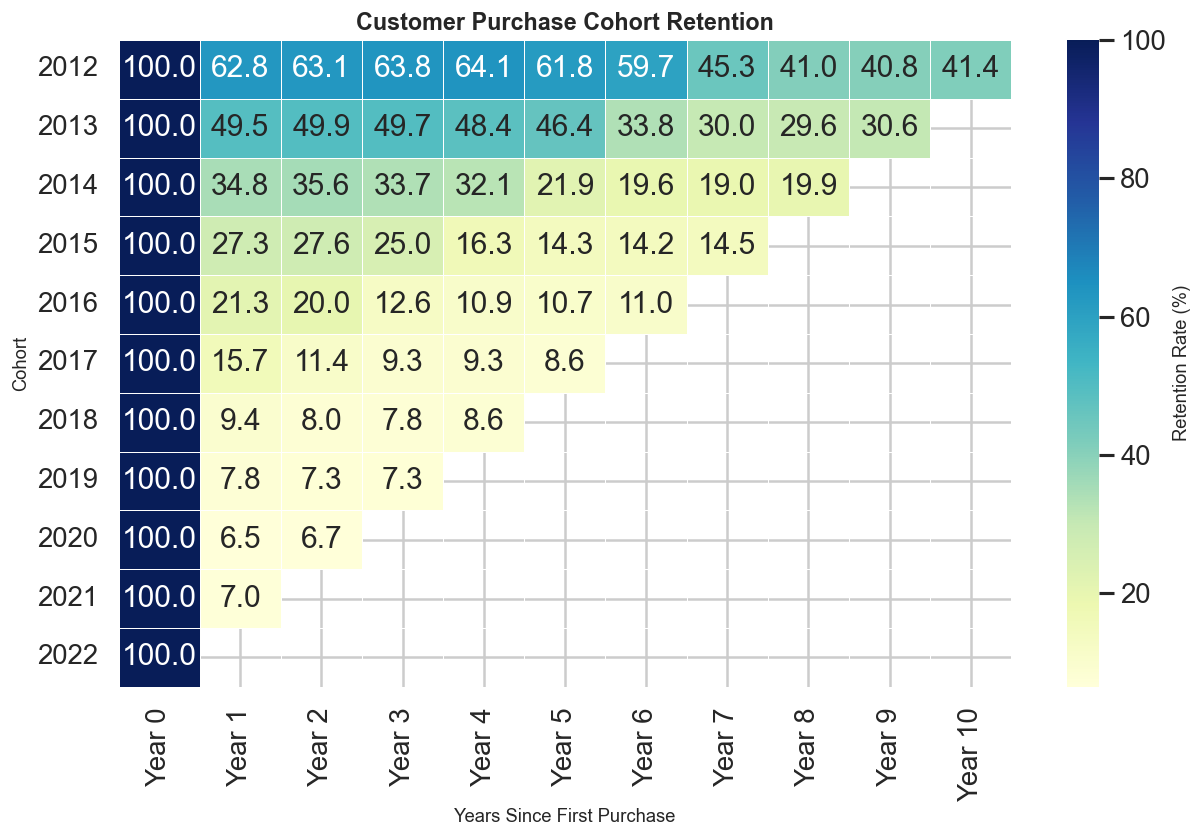

In [6]:
orders_valid = orders.loc[orders["order_status"] != "cancelled", ["customer_id", "order_id", "order_date"]].copy()
orders_valid["order_year"] = orders_valid["order_date"].dt.to_period("Y")

first_purchase = (
    orders_valid.groupby("customer_id")["order_date"]
    .min()
    .dt.to_period("Y")
    .rename("cohort_year")
)

purchase_cohort = orders_valid.merge(first_purchase, on="customer_id", how="left")
purchase_cohort["period_number"] = (purchase_cohort["order_year"] - purchase_cohort["cohort_year"]).apply(lambda x: x.n)

cohort_size = (
    purchase_cohort.loc[purchase_cohort["period_number"] == 0]
    .groupby("cohort_year")["customer_id"]
    .nunique()
    .rename("cohort_size")
)

retention = (
    purchase_cohort.groupby(["cohort_year", "period_number"])["customer_id"]
    .nunique()
    .rename("customers")
    .reset_index()
    .merge(cohort_size, on="cohort_year", how="left")
)
retention["retention_rate"] = retention["customers"] / retention["cohort_size"] * 100

retention_matrix = retention.pivot(index="cohort_year", columns="period_number", values="retention_rate")
retention_matrix.index = retention_matrix.index.astype(str)
retention_matrix.columns = [f"Year {c}" for c in retention_matrix.columns]

plt.figure(figsize=(12, 7))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Retention Rate (%)"}
)
plt.title("Customer Purchase Cohort Retention")
plt.xlabel("Years Since First Purchase")
plt.ylabel("Cohort")
plt.show()
        


**Interpretation**

- Retention chart này giàu insight hơn heatmap cũ vì định nghĩa cohort và mẫu số đều đúng hơn về mặt business.
- Nếu các cohort mới suy giảm retention nhanh hơn cohort cũ, doanh thu tương lai dễ phụ thuộc quá mức vào acquisition/promotion.
- Nếu retention tương đối ổn, đó là nền tốt cho mô hình dự báo vì base demand bớt "mong manh" hơn.
        


## 6. Reverse logistics: count reasons, but normalize refund by revenue

Notebook cũ vẽ `refund_amount` theo thời gian ở dạng raw total. Chart đó nhìn được xu hướng nhưng chưa công bằng, vì khi doanh thu tăng thì refund total cũng có thể tăng theo. Ở đây ta sửa thành:
- Panel trái: **lý do trả hàng phổ biến nhất**.
- Panel phải: **refund rate = refund amount / revenue** theo tháng.

Đây là cách nhìn thực tế hơn về "mức độ rò rỉ" sau bán.
        


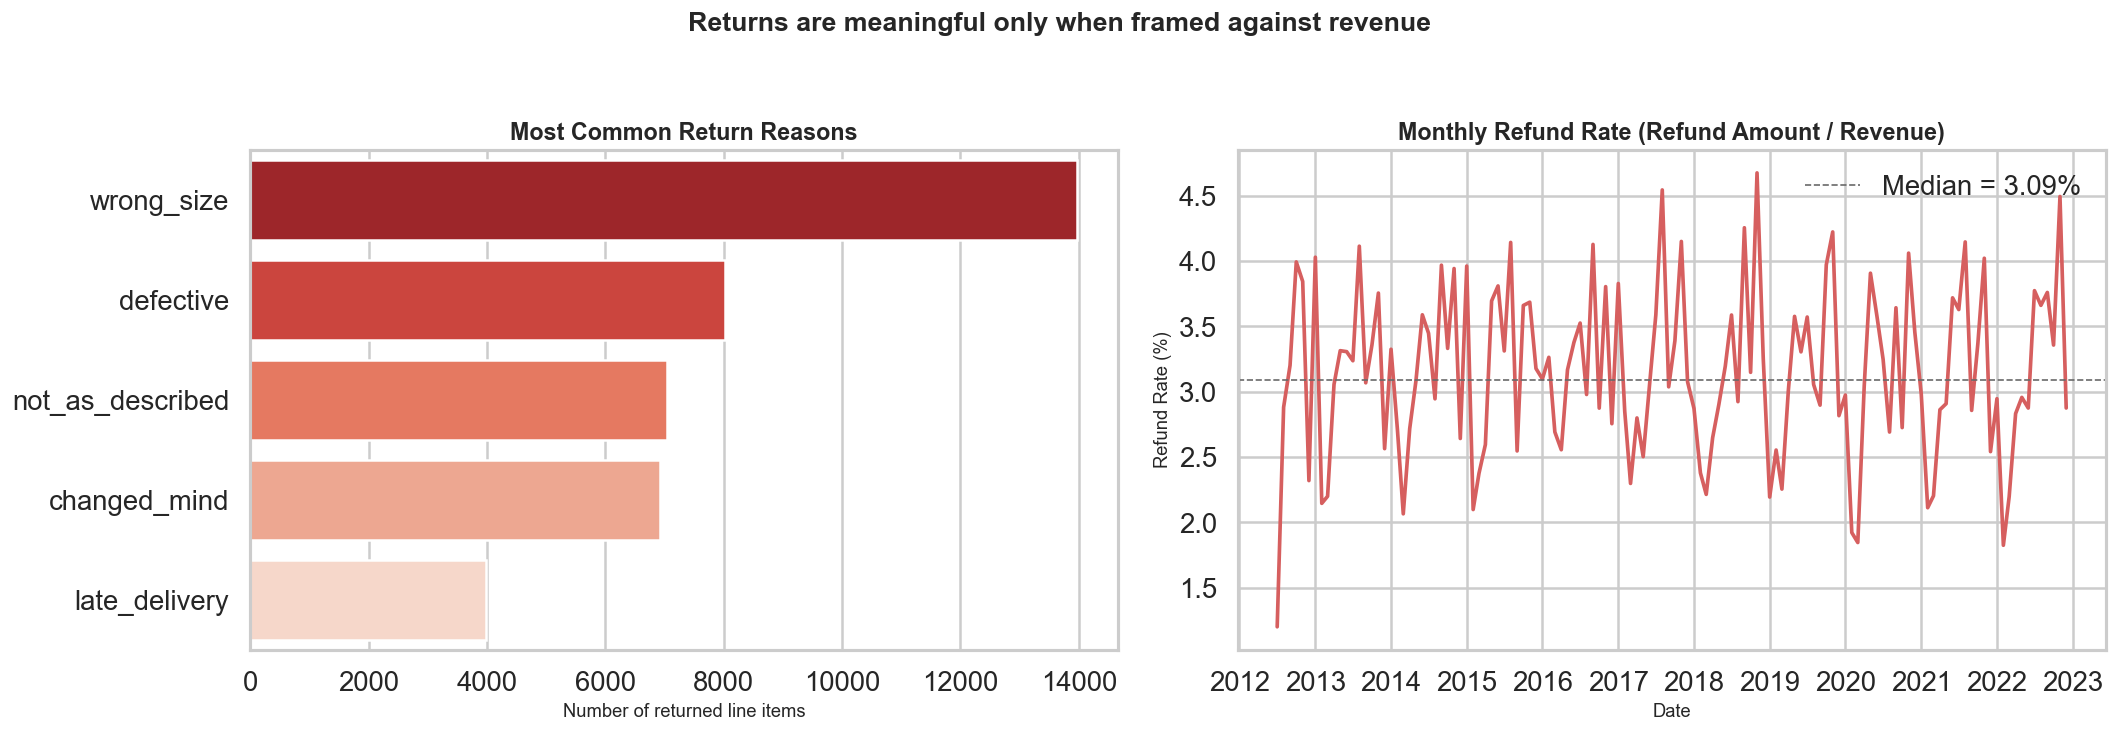

In [7]:
return_reason_counts = (
    returns["return_reason"]
    .value_counts()
    .rename_axis("return_reason")
    .reset_index(name="return_count")
)

monthly_refunds = (
    returns.assign(YearMonth=returns["return_date"].dt.to_period("M").dt.to_timestamp())
           .groupby("YearMonth", as_index=False)["refund_amount"]
           .sum()
)

refund_rate = monthly_sales.merge(monthly_refunds, on="YearMonth", how="left").fillna({"refund_amount": 0})
refund_rate["RefundRatePct"] = refund_rate["refund_amount"] / refund_rate["Revenue"] * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=return_reason_counts,
    y="return_reason",
    x="return_count",
    palette="Reds_r",
    ax=axes[0]
)
axes[0].set_title("Most Common Return Reasons")
axes[0].set_xlabel("Number of returned line items")
axes[0].set_ylabel("")

axes[1].plot(
    refund_rate["YearMonth"],
    refund_rate["RefundRatePct"],
    color=COLORS[3],
    linewidth=2.2
)
axes[1].axhline(
    refund_rate["RefundRatePct"].median(),
    color="dimgray",
    linestyle="--",
    linewidth=1,
    label=f"Median = {refund_rate['RefundRatePct'].median():.2f}%"
)
axes[1].set_title("Monthly Refund Rate (Refund Amount / Revenue)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Refund Rate (%)")
axes[1].legend(loc="upper right")
axes[1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Returns are meaningful only when framed against revenue", y=1.03, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()
        


**Interpretation**

- `wrong_size`, `defective` hay `not_as_described` đều là những lý do trả hàng có thể chuyển hóa thành action rõ ràng về sizing, QC hoặc nội dung catalog.
- Refund rate tốt hơn refund total vì nó cho phép so sánh công bằng giữa các giai đoạn doanh thu khác nhau.
- Nếu refund rate tăng đồng thời với promo intensity, đó là một tín hiệu đáng lưu ý: volume được kéo lên nhưng chất lượng đơn hàng có thể đang xấu đi.
        


## Suggested subset for the 4-page NeurIPS-style report

Nếu report bị giới hạn rất chặt, mình khuyên ưu tiên:

1. **Revenue + Gross Margin trend**  
   Vì đây là bức tranh nền của target cần forecast.

2. **Seasonality heatmap + monthly profile**  
   Vì đây là evidence trực tiếp nhất cho seasonal modeling.

3. **Promotion penetration vs margin**  
   Vì nó vừa có business trade-off vừa gợi ý exogenous features.

4. **Traffic / orders / revenue funnel**  
   Vì nó nối EDA sang forecasting theo hướng demand drivers.

Hai hình còn lại về retention và returns có thể để dạng supporting figure hoặc đưa vào appendix / phần supplement nếu report quá chật.
        


In [14]:
# Kiểm tra có ngày nào Revenue âm không
print(sales[sales['Revenue'] < 0])

# So sánh tổng revenue từ 2 nguồn
total_sales = sales['Revenue'].sum()

_oi = order_items.copy()
#_oi['line_rev'] = _oi['quantity'] * _oi['unit_price'] - _oi['discount_amount'].fillna(0)
_oi['line_rev'] = _oi['quantity'] * _oi['unit_price']
total_orders = _oi['line_rev'].sum()

total_refunds = returns['refund_amount'].sum()

print(f'sales.csv total     : {total_sales:,.0f}')
print(f'orders - refunds    : {total_orders - total_refunds:,.0f}')
print(f'orders only         : {total_orders:,.0f}')
print(f'Diff vs net         : {abs(total_sales - (total_orders - total_refunds)):,.0f}')
print(f'Diff vs gross       : {abs(total_sales - total_orders):,.0f}')
print()

Empty DataFrame
Columns: [Date, Revenue, COGS]
Index: []
sales.csv total     : 16,430,476,586
orders - refunds    : 15,919,878,079
orders only         : 16,430,476,586
Diff vs net         : 510,598,507
Diff vs gross       : 0



In [11]:
total_cogs = sales['COGS'].sum()
print(total_cogs)

14163450519.169998


In [8]:
# Kiểm tra 1: shipping fee có được cộng vào không?

shipments = pd.read_csv("../data/shipments.csv")
payments = pd.read_csv("../data/payments.csv")
total_shipping = shipments['shipping_fee'].sum()
print(f'Total shipping fees : {total_shipping:,.0f}')
print(f'Gross + shipping    : {15_680_869_265 + total_shipping:,.0f}')
print(f'sales.csv total     : {16_430_476_586:,.0f}')

# Kiểm tra 2: có order nào trong orders nhưng không có trong order_items không?
orders_in_oi = set(order_items['order_id'].unique())
orders_all   = set(orders['order_id'].unique())
missing = orders_all - orders_in_oi
print(f'\nOrders không có trong order_items: {len(missing)}')

# Kiểm tra 3: payment_value có khớp hơn không?
total_payment = payments['payment_value'].sum()
print(f'\nTotal payment_value : {total_payment:,.0f}')
print(f'Diff vs sales.csv   : {abs(16_430_476_586 - total_payment):,.0f}')

Total shipping fees : 2,809,310
Gross + shipping    : 15,683,678,575
sales.csv total     : 16,430,476,586

Orders không có trong order_items: 0

Total payment_value : 15,680,869,265
Diff vs sales.csv   : 749,607,321


In [9]:
# Kiểm tra thêm để confirm: correlation theo ngày
daily_from_orders = (
    order_items.merge(orders[['order_id','order_date']], on='order_id')
    .assign(line_rev=lambda df: df['quantity']*df['unit_price'] - df['discount_amount'].fillna(0))
    .groupby('order_date')['line_rev'].sum()
    .reset_index()
    .rename(columns={'order_date':'Date', 'line_rev':'Rev_orders'})
)
daily_from_orders['Date'] = pd.to_datetime(daily_from_orders['Date'])

compare = sales.merge(daily_from_orders, on='Date', how='inner')
corr = compare['Revenue'].corr(compare['Rev_orders'])
ratio = (compare['Revenue'] / compare['Rev_orders']).describe()

print(f'Correlation daily Revenue vs order_items: {corr:.4f}')
print(f'\nRatio sales/orders by day:')
print(ratio.round(3))

Correlation daily Revenue vs order_items: 0.9921

Ratio sales/orders by day:
count    3833.000
mean        1.062
std         0.090
min         1.000
25%         1.000
50%         1.000
75%         1.111
max         1.250
dtype: float64


In [ ]:
# Tính toán theo tháng từ bảng sales
sales_monthly = sales.set_index('Date').resample('MS').sum()
sales_monthly['Gross Margin'] = sales_monthly['Revenue'] - sales_monthly['COGS']
sales_monthly['Gross Margin %'] = (sales_monthly['Gross Margin'] / sales_monthly['Revenue']) * 100
sales_monthly['Revenue 12M Rolling'] = sales_monthly['Revenue'].rolling(window=12, min_periods=1).mean()

# Số lượng đơn hàng theo tháng từ bảng orders
orders_monthly = orders.set_index('order_date').resample('MS').size().to_frame(name='Number of Orders')

# Gộp dữ liệu
monthly_data = sales_monthly.join(orders_monthly, how='inner')

# Trực quan hóa gộp trên 1 hình
fig, ax1 = plt.subplots(figsize=(14, 8))

# 1. Revenue (Trục y bên trái)
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue', color=COLORS[0])
line1 = ax1.plot(monthly_data.index, monthly_data['Revenue'], marker='o', color=COLORS[0], label='Monthly Revenue')
line2 = ax1.plot(monthly_data.index, monthly_data['Revenue 12M Rolling'], linestyle='--', color='red', label='12-Month Rolling Mean')
ax1.tick_params(axis='y', labelcolor=COLORS[0])

# 2. Number of Orders (Trục y bên phải thứ nhất)
ax2 = ax1.twinx()
ax2.set_ylabel('Number of Orders', color=COLORS[2])
line3 = ax2.plot(monthly_data.index, monthly_data['Number of Orders'], marker='s', color=COLORS[2], label='Number of Orders')
ax2.tick_params(axis='y', labelcolor=COLORS[2])

# 3. Gross Margin % (Trục y bên phải thứ hai, dời ra ngoài chút để không đè lên Number of Orders)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.set_ylabel('Gross Margin (%)', color=COLORS[1])
line4 = ax3.plot(monthly_data.index, monthly_data['Gross Margin %'], marker='^', color=COLORS[1], label='Gross Margin %')
ax3.tick_params(axis='y', labelcolor=COLORS[1])

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, linestyle='--', alpha=0.7)

lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Revenue, Orders & Gross Margin % over Time')
fig.tight_layout()
plt.show()
